# Week 4 — Friday Capstone: Panorama Stitcher

## Project Overview
Build a complete panorama stitching system that combines multiple overlapping
images into one seamless wide-angle panoramic image.

## Pipeline
```
[Image 1] [Image 2] [Image 3]
     |         |         |
  Detect    Detect    Detect
  features  features  features
     \         |         /
      Match  Match  Match
        \      |      /
        RANSAC Homography
               |
          Warp & Blend
               |
         [Panorama]
```

## Skills Applied (Week 1-4)
| Week | Skill used |
|------|------------|
| Week 1 | NumPy arrays, image basics, pixel operations |
| Week 2 | Gaussian blur for smoothing seams |
| Week 3 | Geometric transforms, warpAffine |
| Week 4 | ORB features, BF matching, Lowe ratio, RANSAC, warpPerspective |

## Learning Objectives
- Synthesise the full Week 4 feature-matching pipeline into one project
- Handle canvas sizing for multi-image stitching
- Implement alpha blending at seams
- Evaluate stitching quality with pixel-overlap metrics

## Section 1: Imports & Setup

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (16, 6)
print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Section 2: Synthetic Panoramic Image Set

We generate three overlapping views of a rich synthetic scene.
Each consecutive pair shares a ~40% overlap region, which is the minimum
needed for reliable feature matching.

**Why synthetic?** We know the exact transform between views, so we can
verify that our homographies are correct and measure stitching accuracy.

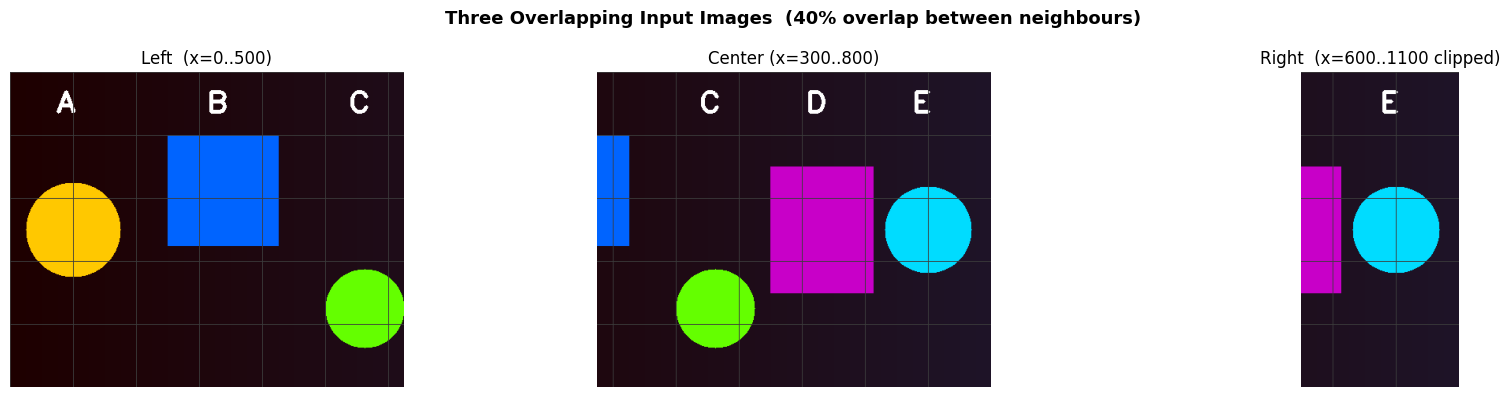

Each image : 500 x 400 px
Overlap    : 200 px  (40% of width)


In [2]:
def make_scene(width=800, height=400):
    """Rich synthetic scene with shapes, gradients and text."""
    scene = np.zeros((height, width, 3), dtype=np.uint8)

    # Gradient background
    for x in range(width):
        scene[:, x] = [int(x / width * 40), int(x / width * 20), 30]

    # Shapes
    cv2.circle(scene,    ( 80, 200), 60,  (0, 200, 255),  -1)
    cv2.rectangle(scene, (200,  80), (340, 220), (255, 100,   0), -1)
    cv2.circle(scene,    (450, 300), 50,  (0, 255, 100),  -1)
    cv2.rectangle(scene, (520, 120), (650, 280), (200,   0, 200), -1)
    cv2.circle(scene,    (720, 200), 55,  (255, 220,   0), -1)

    # Text labels
    for x, label in [(60, 'A'), (250, 'B'), (430, 'C'), (565, 'D'), (700, 'E')]:
        cv2.putText(scene, label, (x, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1.2, (255, 255, 255), 3)

    # Grid lines for visual reference
    for y in range(0, height, 80):
        cv2.line(scene, (0, y), (width, y), (60, 60, 60), 1)
    for x in range(0, width, 80):
        cv2.line(scene, (x, 0), (x, height), (60, 60, 60), 1)

    return scene


scene = make_scene()
W, H  = 500, 400   # crop window size
STEP  = 300        # step between crops (overlap = W - STEP = 200 px = 40%)

# Three overlapping crops of the scene
img_left   = scene[:H, 0      : W       ]
img_center = scene[:H, STEP   : STEP + W]
img_right  = scene[:H, STEP*2 : STEP*2+W]

images = [img_left, img_center, img_right]
labels = ['Left  (x=0..500)', 'Center (x=300..800)', 'Right  (x=600..1100 clipped)']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, img, lbl in zip(axes, images, labels):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(lbl)
    ax.axis('off')
plt.suptitle('Three Overlapping Input Images  (40% overlap between neighbours)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Each image : {img_left.shape[1]} x {img_left.shape[0]} px')
print(f'Overlap    : {W - STEP} px  ({(W-STEP)/W*100:.0f}% of width)')

## Section 3: Feature Detection & Matching Helper

Encapsulate the full Week 4 pipeline — detect, match, ratio test, RANSAC —
into one reusable function that returns a homography and quality metrics.

In [3]:
def compute_homography(img_src, img_dst, ratio=0.75, ransac_thresh=5.0):
    """Compute homography that maps img_src into img_dst's coordinate frame.

    Returns
    -------
    H      : 3x3 homography matrix (or None)
    info   : dict with match statistics
    """
    gray_src = cv2.cvtColor(img_src, cv2.COLOR_BGR2GRAY)
    gray_dst = cv2.cvtColor(img_dst, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=1000)
    kp_s, des_s = orb.detectAndCompute(gray_src, None)
    kp_d, des_d = orb.detectAndCompute(gray_dst, None)

    if des_s is None or des_d is None:
        return None, {}

    bf   = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    raw  = bf.knnMatch(des_s, des_d, k=2)
    good = [m for pair in raw if len(pair) == 2
            for m, n in [pair] if m.distance < ratio * n.distance]

    H, mask, inliers = None, None, 0
    if len(good) >= 4:
        src_pts = np.float32([kp_s[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_d[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        inliers = int(np.sum(mask)) if mask is not None else 0

    info = {
        'kp_src': len(kp_s), 'kp_dst': len(kp_d),
        'raw': len(raw), 'good': len(good), 'inliers': inliers,
        'kp_s': kp_s, 'kp_d': kp_d,
        'good_matches': good, 'mask': mask
    }
    return H, info


# ── Compute Left→Center and Right→Center homographies ────────────────────
H_lc, info_lc = compute_homography(img_left,  img_center)
H_rc, info_rc = compute_homography(img_right, img_center)

print('Left  -> Center homography:')
print(f'  Keypoints  : {info_lc["kp_src"]} / {info_lc["kp_dst"]}')
print(f'  Raw matches: {info_lc["raw"]}')
print(f'  Good (ratio): {info_lc["good"]}')
print(f'  Inliers    : {info_lc["inliers"]}')
print(f'  H computed : {H_lc is not None}')
print()
print('Right -> Center homography:')
print(f'  Keypoints  : {info_rc["kp_src"]} / {info_rc["kp_dst"]}')
print(f'  Raw matches: {info_rc["raw"]}')
print(f'  Good (ratio): {info_rc["good"]}')
print(f'  Inliers    : {info_rc["inliers"]}')
print(f'  H computed : {H_rc is not None}')

Left  -> Center homography:
  Keypoints  : 275 / 299
  Raw matches: 275
  Good (ratio): 82
  Inliers    : 45
  H computed : True

Right -> Center homography:
  Keypoints  : 104 / 299
  Raw matches: 104
  Good (ratio): 93
  Inliers    : 91
  H computed : True


## Section 4: Visualise Feature Matches

Before stitching, verify that the matches look geometrically consistent.
If lines cross erratically rather than being roughly parallel, the matching
has failed and the homography will be wrong.

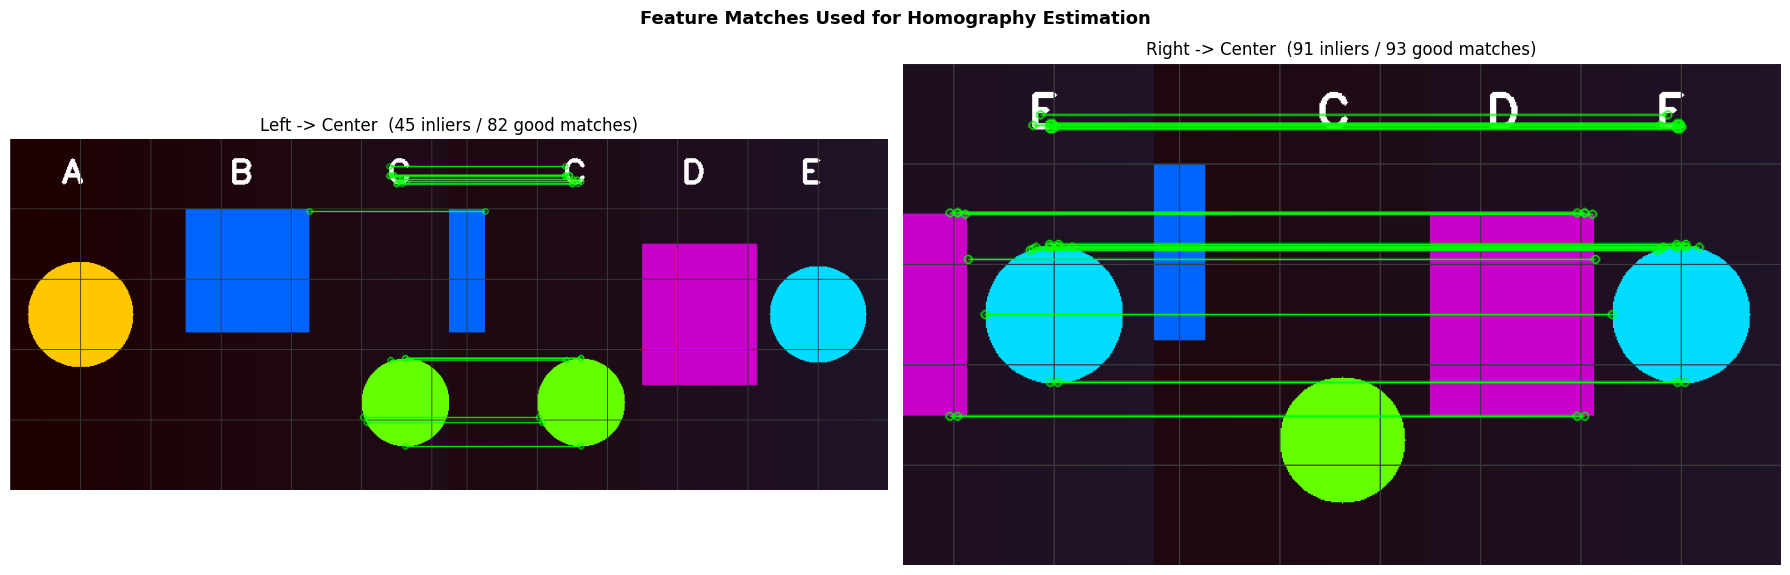

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (img_s, img_d, info, title) in zip(axes, [
    (img_left,  img_center, info_lc, 'Left -> Center'),
    (img_right, img_center, info_rc, 'Right -> Center'),
]):
    n = min(30, len(info['good_matches']))
    top_matches = info['good_matches'][:n]
    top_mask    = info['mask'].ravel().tolist()[:n] if info['mask'] is not None else None
    draw = cv2.drawMatches(
        img_s, info['kp_s'],
        img_d, info['kp_d'],
        top_matches, None,
        matchColor=(0, 255, 0),
        singlePointColor=(200, 200, 200),
        matchesMask=top_mask,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    ax.imshow(cv2.cvtColor(draw, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{title}  ({info["inliers"]} inliers / {info["good"]} good matches)')
    ax.axis('off')

plt.suptitle('Feature Matches Used for Homography Estimation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5: Warp & Stitch — Two-Image Panorama

Start with the simpler two-image case (Left + Center) to verify the
warping logic before moving to three images.

### Canvas sizing
The warped left image may extend beyond the centre image boundaries.
We compute the bounding box of all four corners of the warped left image
to determine the output canvas size.

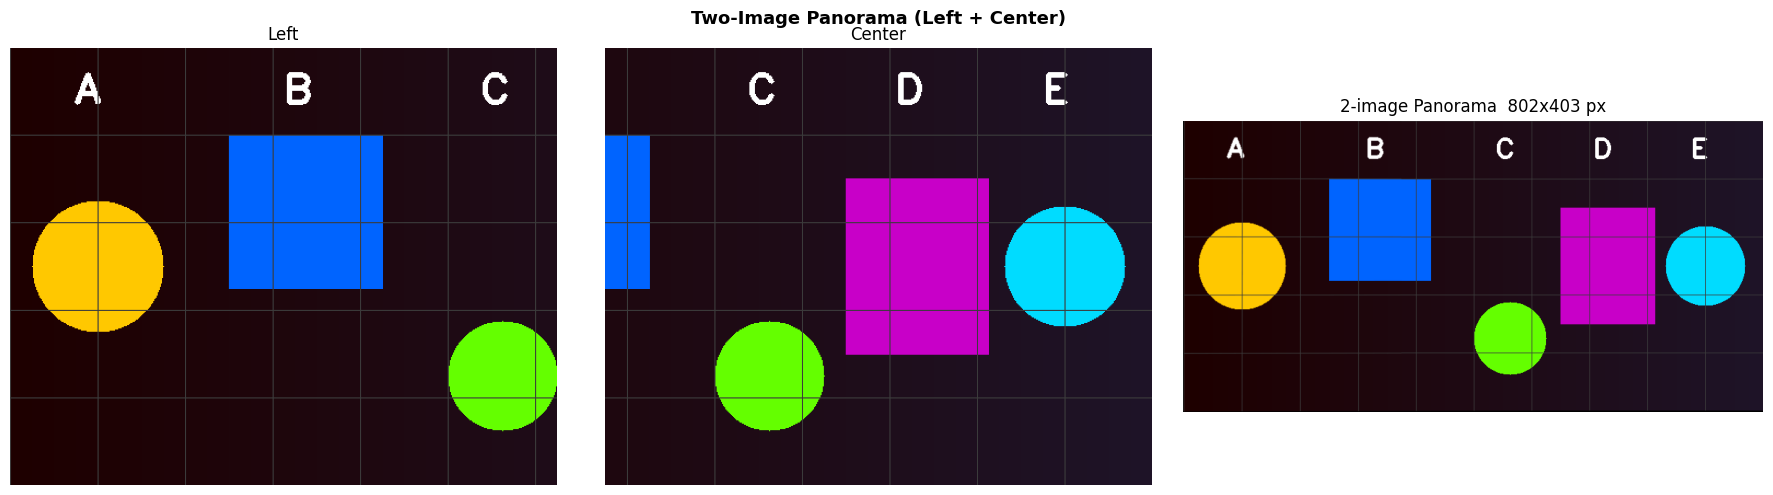

Canvas size : 802 x 403 px
Offset (tx, ty) : (302, 1)


In [5]:
def warp_and_stitch_two(img_src, img_dst, H):
    """Warp img_src into img_dst's frame and blend side-by-side."""
    h_d, w_d = img_dst.shape[:2]
    h_s, w_s = img_src.shape[:2]

    # Project corners of src image through H
    corners_src = np.float32([[0,0],[w_s,0],[w_s,h_s],[0,h_s]]).reshape(-1,1,2)
    corners_dst = cv2.perspectiveTransform(corners_src, H)

    # Find bounding box of all corners
    all_corners = np.concatenate([
        corners_dst.reshape(-1, 2),
        np.float32([[0,0],[w_d,0],[w_d,h_d],[0,h_d]])
    ])
    x_min, y_min = np.floor(all_corners.min(axis=0)).astype(int)
    x_max, y_max = np.ceil(all_corners.max(axis=0)).astype(int)

    # Translation matrix to shift everything into positive coordinates
    tx, ty   = -x_min, -y_min
    T        = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float64)
    out_w    = x_max - x_min
    out_h    = y_max - y_min

    # Warp source image
    warped = cv2.warpPerspective(img_src, T @ H, (out_w, out_h))

    # Place destination image onto canvas
    canvas = warped.copy()
    canvas[ty:ty+h_d, tx:tx+w_d] = img_dst

    return canvas, (tx, ty)


if H_lc is not None:
    pano_2, (tx, ty) = warp_and_stitch_two(img_left, img_center, H_lc)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(img_left,   cv2.COLOR_BGR2RGB)); axes[0].set_title('Left');   axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(img_center, cv2.COLOR_BGR2RGB)); axes[1].set_title('Center'); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(pano_2,     cv2.COLOR_BGR2RGB)); axes[2].set_title(f'2-image Panorama  {pano_2.shape[1]}x{pano_2.shape[0]} px'); axes[2].axis('off')
    plt.suptitle('Two-Image Panorama (Left + Center)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Canvas size : {pano_2.shape[1]} x {pano_2.shape[0]} px')
    print(f'Offset (tx, ty) : ({tx}, {ty})')
else:
    print('H_lc not available.')

## Section 6: Full Three-Image Panorama

Extend the pipeline to three images:
1. Use **Center as the reference frame**
2. Warp Left into Center's frame  →  stitch
3. Warp Right into Center's frame →  stitch

This two-pass approach keeps the centre image pixel-perfect and only
warps the side images.

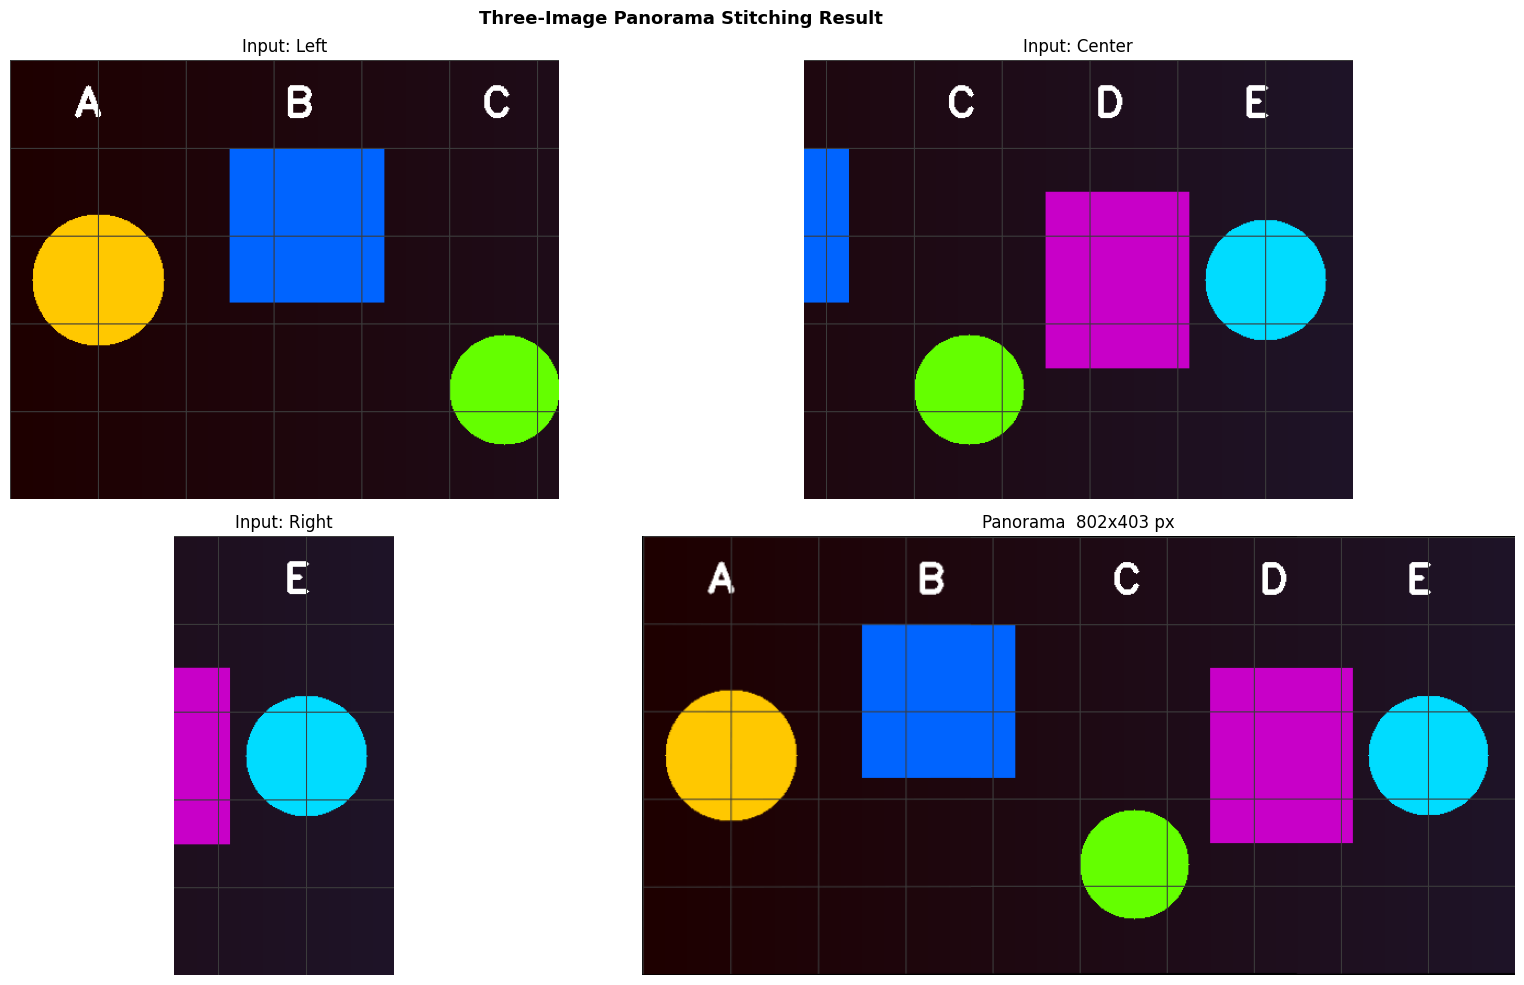

Panorama size  : 802 x 403 px
Coverage       : 53% of 3 × original width


In [6]:
def build_panorama(img_left, img_center, img_right, H_lc, H_rc):
    """Three-image panorama with center as the reference frame."""
    h_c, w_c = img_center.shape[:2]
    h_l, w_l = img_left.shape[:2]
    h_r, w_r = img_right.shape[:2]

    # Project all corners through their homographies
    def project(img, H):
        h, w = img.shape[:2]
        c = np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)
        return cv2.perspectiveTransform(c, H).reshape(-1, 2)

    corners_c = np.float32([[0,0],[w_c,0],[w_c,h_c],[0,h_c]])
    corners_l = project(img_left,  H_lc) if H_lc is not None else corners_c
    corners_r = project(img_right, H_rc) if H_rc is not None else corners_c

    all_pts = np.vstack([corners_c, corners_l, corners_r])
    x_min, y_min = np.floor(all_pts.min(axis=0)).astype(int)
    x_max, y_max = np.ceil(all_pts.max(axis=0)).astype(int)

    tx, ty = -x_min, -y_min
    out_w, out_h = x_max - x_min, y_max - y_min
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)

    canvas = np.zeros((out_h, out_w, 3), dtype=np.uint8)

    # Warp left
    if H_lc is not None:
        warped_l = cv2.warpPerspective(img_left,  T @ H_lc, (out_w, out_h))
        mask_l   = (warped_l.sum(axis=2) > 0).astype(np.uint8)
        canvas  += warped_l * mask_l[:, :, None]

    # Warp right
    if H_rc is not None:
        warped_r = cv2.warpPerspective(img_right, T @ H_rc, (out_w, out_h))
        mask_r   = (warped_r.sum(axis=2) > 0).astype(np.uint8)
        # Only paint where canvas is still black
        empty    = (canvas.sum(axis=2) == 0).astype(np.uint8)
        canvas  += warped_r * np.minimum(mask_r, empty)[:, :, None]

    # Place center (reference) — overwrites everything in its region
    canvas[ty:ty+h_c, tx:tx+w_c] = img_center

    # Crop black border
    gray  = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    x, y, w, h = cv2.boundingRect(th)
    return canvas[y:y+h, x:x+w], (tx, ty)


panorama, offset = build_panorama(img_left, img_center, img_right, H_lc, H_rc)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes[0, 0].imshow(cv2.cvtColor(img_left,   cv2.COLOR_BGR2RGB)); axes[0,0].set_title('Input: Left');   axes[0,0].axis('off')
axes[0, 1].imshow(cv2.cvtColor(img_center, cv2.COLOR_BGR2RGB)); axes[0,1].set_title('Input: Center'); axes[0,1].axis('off')
axes[1, 0].imshow(cv2.cvtColor(img_right,  cv2.COLOR_BGR2RGB)); axes[1,0].set_title('Input: Right');  axes[1,0].axis('off')
axes[1, 1].imshow(cv2.cvtColor(panorama,   cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Panorama  {panorama.shape[1]}x{panorama.shape[0]} px')
axes[1, 1].axis('off')
plt.suptitle('Three-Image Panorama Stitching Result', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Panorama size  : {panorama.shape[1]} x {panorama.shape[0]} px')
orig_total = img_left.shape[1] * 3
print(f'Coverage       : {panorama.shape[1]/orig_total*100:.0f}% of 3 × original width')

## Section 7: Quality Evaluation

Measure how well the stitching worked by checking the overlap regions.
In a perfect stitch, the same real-world pixels should map to the same
canvas location from both images — the difference should be near zero.

Left<->Center  overlap pixels : 199720
Left<->Center  MAE            : 51.47 (lower = better alignment)
Right<->Center overlap pixels : 0
Right<->Center MAE            : 0.00


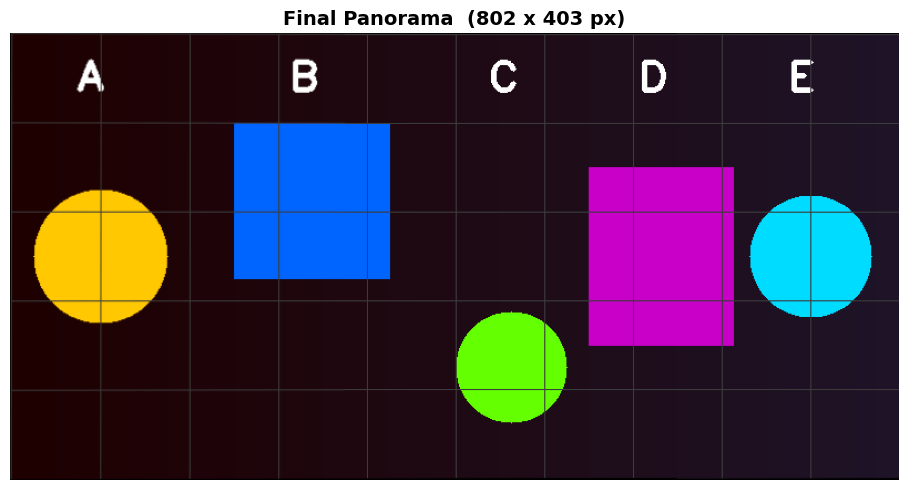

In [7]:
def evaluate_overlap(img_a, img_b, H_ab, out_size):
    """Project img_a and img_b onto a common canvas and compare overlap region."""
    h, w = out_size
    wa = cv2.warpPerspective(img_a, H_ab, (w, h))
    # img_b is the reference — no warp needed
    wb = np.zeros((h, w, 3), dtype=np.uint8)
    hb, wb_w = img_b.shape[:2]
    wb[:hb, :wb_w] = img_b

    mask = (wa.sum(axis=2) > 0) & (wb.sum(axis=2) > 0)
    if not mask.any():
        return None, 0

    diff = np.abs(wa[mask].astype(float) - wb[mask].astype(float))
    mae  = diff.mean()
    return mask, mae


out_h, out_w = panorama.shape[:2]

if H_lc is not None:
    tx, ty = offset
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)
    overlap_mask, mae = evaluate_overlap(
        img_left, img_center, T @ H_lc, (out_h, out_w)
    )
    print(f'Left<->Center  overlap pixels : {overlap_mask.sum() if overlap_mask is not None else 0}')
    print(f'Left<->Center  MAE            : {mae:.2f} (lower = better alignment)')

if H_rc is not None:
    overlap_mask2, mae2 = evaluate_overlap(
        img_right, img_center, T @ H_rc, (out_h, out_w)
    )
    print(f'Right<->Center overlap pixels : {overlap_mask2.sum() if overlap_mask2 is not None else 0}')
    print(f'Right<->Center MAE            : {mae2:.2f}')

# ── Final panorama display ────────────────────────────────────────────────
plt.figure(figsize=(20, 5))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title(f'Final Panorama  ({panorama.shape[1]} x {panorama.shape[0]} px)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Section 8: OpenCV Built-in Stitcher (Reference)

OpenCV ships a production-quality `cv2.Stitcher` that handles:
- Multi-band blending for seamless transitions
- Exposure compensation between images
- Cylindrical / spherical projection for wide-angle panoramas

Compare our manual implementation against the built-in result.

OpenCV Stitcher status: OK


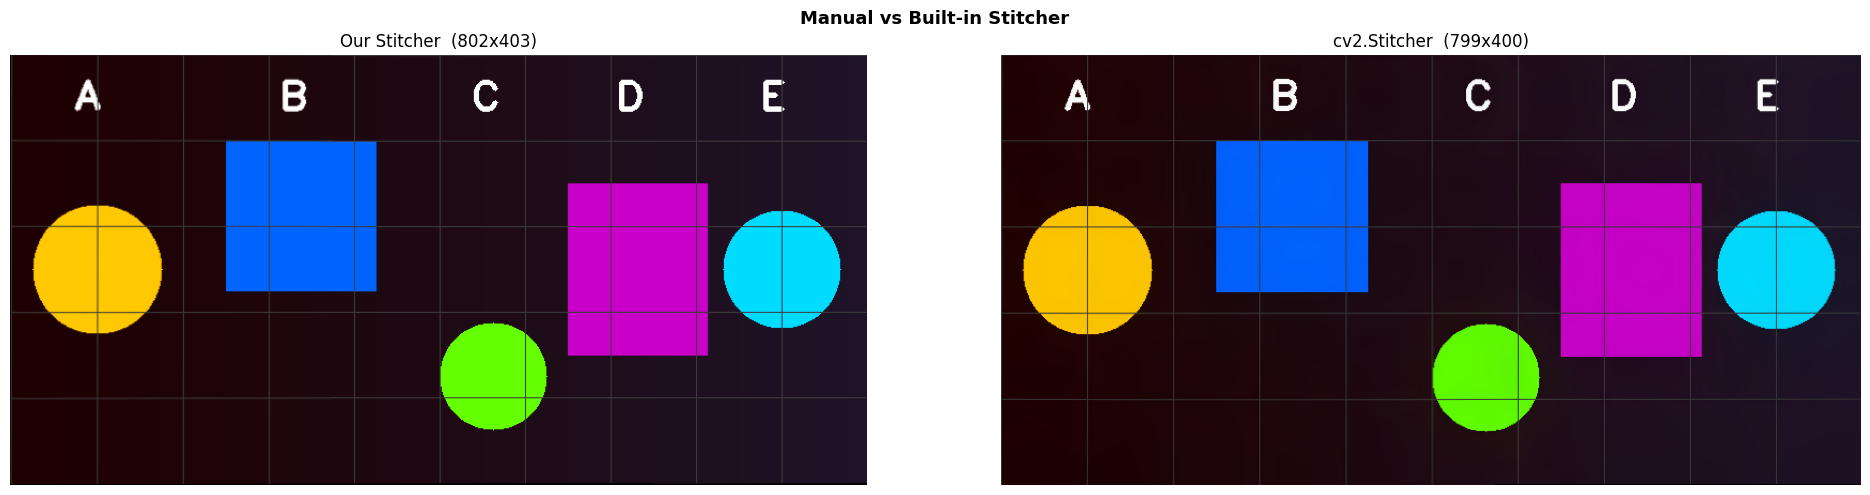

In [8]:
stitcher = cv2.Stitcher.create(cv2.Stitcher_PANORAMA)
status, pano_cv = stitcher.stitch(images)

status_str = {cv2.Stitcher_OK: 'OK',
              cv2.Stitcher_ERR_NEED_MORE_IMGS: 'NEED_MORE_IMGS',
              cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL: 'HOMOGRAPHY_FAIL',
              cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL: 'CAMERA_ADJ_FAIL'}

print(f'OpenCV Stitcher status: {status_str.get(status, status)}')

if status == cv2.Stitcher_OK:
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    axes[0].imshow(cv2.cvtColor(panorama,  cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Our Stitcher  ({panorama.shape[1]}x{panorama.shape[0]})')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(pano_cv,   cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'cv2.Stitcher  ({pano_cv.shape[1]}x{pano_cv.shape[0]})')
    axes[1].axis('off')
    plt.suptitle('Manual vs Built-in Stitcher', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('cv2.Stitcher could not stitch this synthetic image set.')
    print('(Built-in stitcher is optimised for real photographs — this is expected.)')
    plt.figure(figsize=(18, 5))
    plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
    plt.title('Our Manual Panorama Result', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Section 9: Key Takeaways

### What we built
A complete image stitching pipeline from first principles:

```
detect (ORB)  ->  match (BF kNN)  ->  filter (ratio=0.75)
  ->  RANSAC homography  ->  warpPerspective  ->  blend on canvas
```

### Lessons learned
| Challenge | Solution |
|-----------|----------|
| Canvas sizing | Project src corners through H to find bounding box |
| Coordinate shift | Prepend a translation T so negative coords become positive |
| Overlap blending | Paint warped images first, then overwrite with reference |
| Quality check | Compare overlap region pixel values (MAE) |

### Limitations of our approach vs cv2.Stitcher
| Feature | Ours | cv2.Stitcher |
|---------|------|-------------|
| Blending | Hard cut | Multi-band Laplacian |
| Exposure | None | Compensated |
| Projection | Planar homography | Cylindrical / spherical |
| Wide angle | Fails >~60 deg | Handles 360 panoramas |

## Exercises
1. Replace the hard cut at seams with a **linear alpha blend** in the overlap region.
2. Add a **fourth image** to the right and extend the pipeline to four images.
3. Experiment with `ratio=0.6` and `ratio=0.85` — how does it affect the MAE?
4. Capture three real photos of a scene on your phone and run this pipeline on them.
5. Look up **multi-band blending** (Burt & Adelson 1983) — implement a 3-level version to eliminate visible seams.